# **SHAP Analysis — Giải thích Model**

## **0. Import package**

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings("ignore")

from src.data_loader import load_telco, split_features_target
from src.preprocessor import encode_features, add_engineered_features, split_data
from src.shap_analysis import (
    compute_shap_values,
    plot_shap_summary,
    plot_shap_importance,
    plot_shap_dependence,
    plot_shap_waterfall_single,
)

IMAGES = "../images"

df = load_telco("../data/Telco-Customer-Churn.csv")

X_raw, y = split_features_target(df)

X_enc = encode_features(X_raw)
X_eng = add_engineered_features(X_enc)
X_model = X_eng.select_dtypes(include=[np.number]).fillna(X_eng.select_dtypes(include=[np.number]).median())

X_train, X_test, y_train, y_test = split_data(X_model, y)

best_model = joblib.load("../data/best_model.pkl")
print(f"Model loaded: {type(best_model).__name__}")

Model loaded: Pipeline


## **1. Compute SHAP values**

In [2]:
if hasattr(best_model, "named_steps"):
    model_for_shap = best_model.named_steps["model"]
    X_for_shap = pd.DataFrame(
        best_model.named_steps["scaler"].transform(X_test),
        columns=X_test.columns
    )
else:
    model_for_shap = best_model
    X_for_shap = X_test

shap_values, explainer, X_sample = compute_shap_values(
    model_for_shap,
    X_for_shap,
    sample_size=500,
)
print(f"SHAP values shape: {shap_values.shape}")

  0%|          | 0/500 [00:00<?, ?it/s]

SHAP values shape: (500, 27, 2)


## **2. Feature Importance (SHAP-based)**

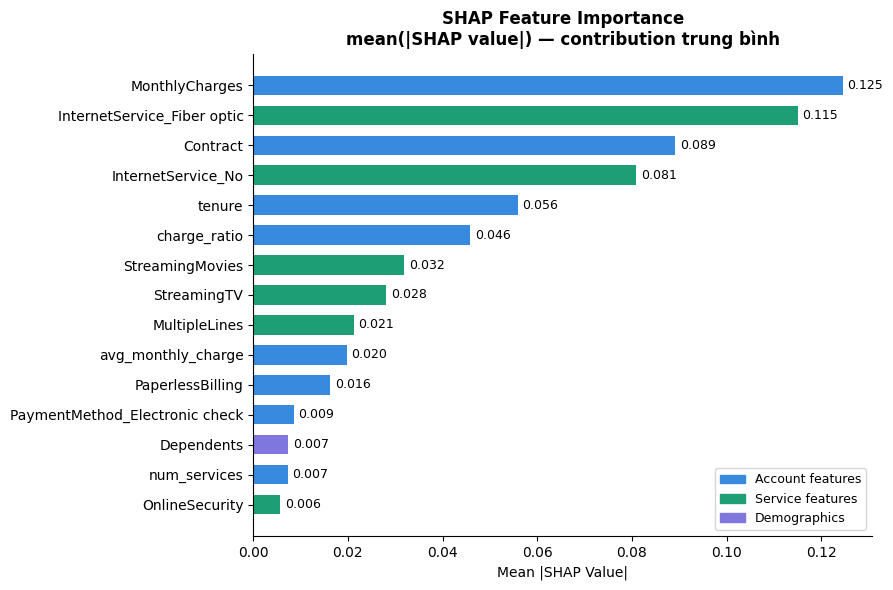

In [5]:
plot_shap_importance(
    shap_values, X_sample,
    save_path=f"{IMAGES}/shap_importance.png",
    top_n=15,
)

## **3. Dependence Plots**

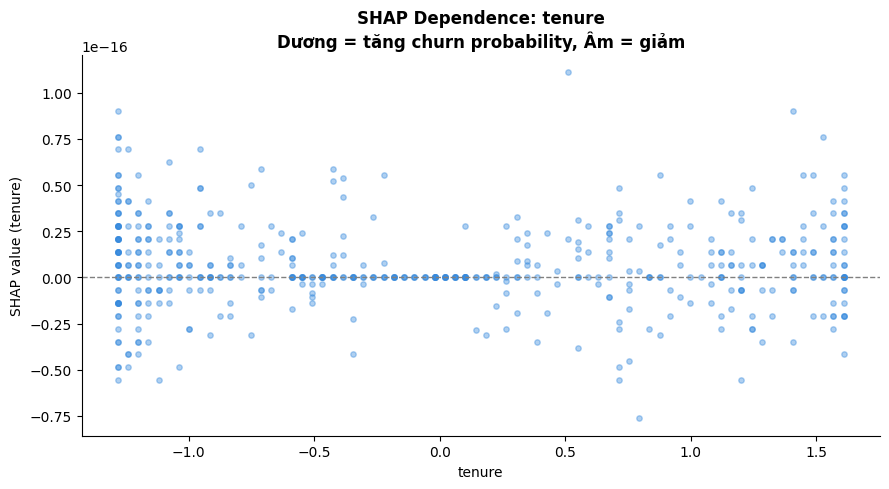

Insight: Tenure thấp → SHAP dương cao → tăng churn mạnh
Tenure > 36 tháng → SHAP âm → ít churn hơn


In [6]:
plot_shap_dependence(
    shap_values, X_sample,
    feature="tenure",
    save_path=f"{IMAGES}/shap_dependence_tenure.png",
)
print("Insight: Tenure thấp → SHAP dương cao → tăng churn mạnh")
print("Tenure > 36 tháng → SHAP âm → ít churn hơn")

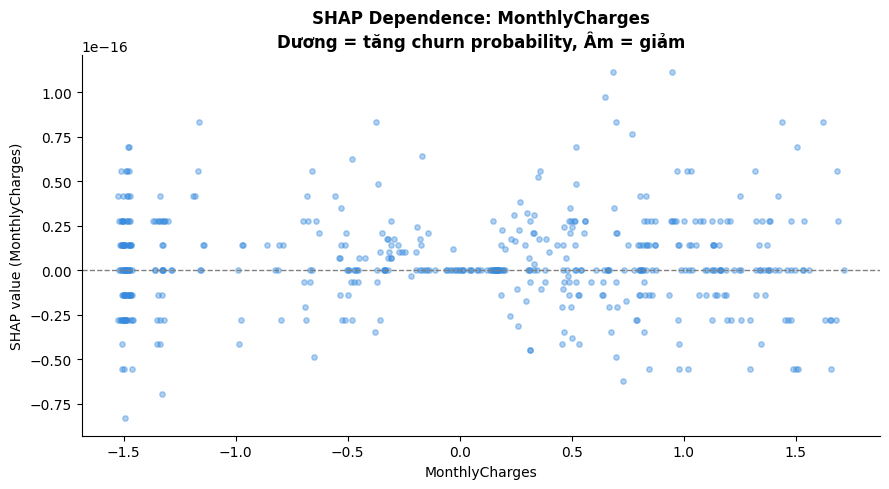

Insight: MonthlyCharges cao → SHAP dương → tăng churn
Khách trả nhiều tiền nhưng vẫn rời đi → vấn đề về value for money


In [7]:
if "MonthlyCharges" in X_sample.columns:
    plot_shap_dependence(
        shap_values, X_sample,
        feature="MonthlyCharges",
        save_path=f"{IMAGES}/shap_dependence_monthly.png",
    )
    print("Insight: MonthlyCharges cao → SHAP dương → tăng churn")
    print("Khách trả nhiều tiền nhưng vẫn rời đi → vấn đề về value for money")

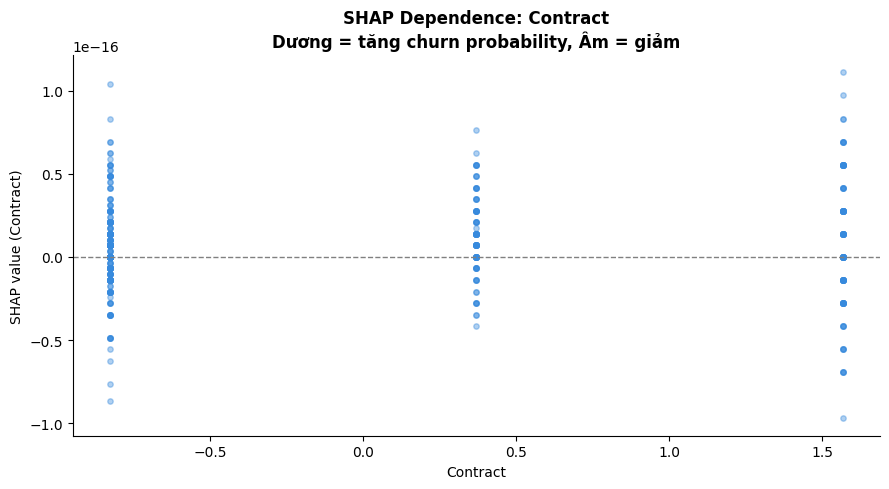

Insight: Contract=0 (Month-to-month) → SHAP dương lớn nhất


In [8]:
if "Contract" in X_sample.columns:
    plot_shap_dependence(
        shap_values, X_sample,
        feature="Contract",
        save_path=f"{IMAGES}/shap_dependence_contract.png",
    )
    print("Insight: Contract=0 (Month-to-month) → SHAP dương lớn nhất")

## **5. Waterfall Plot — Test 1 customer cụ thể**

In [9]:
y_prob_all = best_model.predict_proba(X_test)[:, 1]
high_churn_idx = np.argsort(y_prob_all)[-1]  # Customer có prob cao nhất

print(f"Customer #{high_churn_idx} — Churn probability: {y_prob_all[high_churn_idx]:.1%}")
print("\nThông tin customer:")
print(X_test.iloc[high_churn_idx][
    ["tenure", "MonthlyCharges", "Contract", "TechSupport"]
    if all(c in X_test.columns for c in ["tenure", "MonthlyCharges", "Contract", "TechSupport"])
    else X_test.columns[:5]
])

Customer #1090 — Churn probability: 98.0%

Thông tin customer:
tenure             1.0
MonthlyCharges    95.1
Contract           0.0
TechSupport        0.0
Name: 3380, dtype: float64


  0%|          | 0/1 [00:00<?, ?it/s]

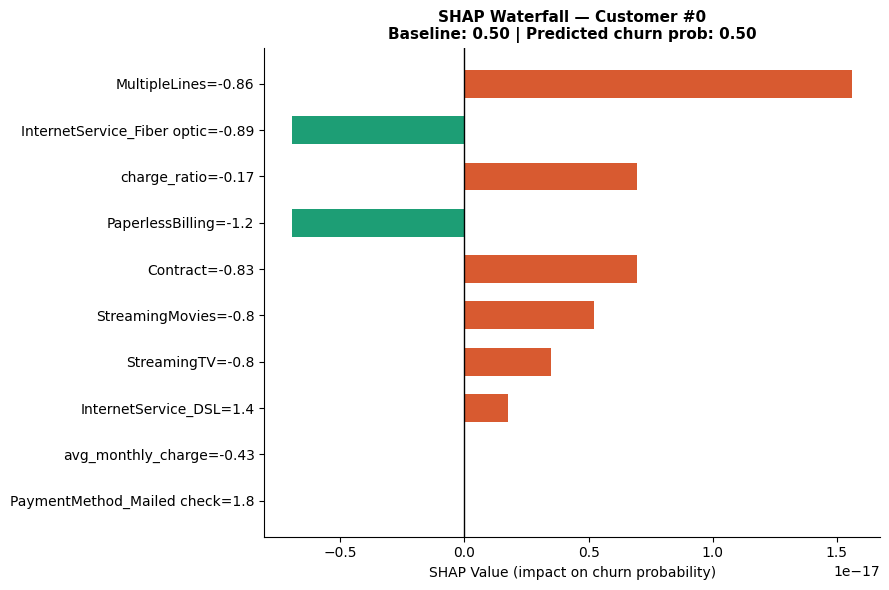

In [10]:
plot_shap_waterfall_single(
    explainer, X_sample,
    customer_idx=0,
    save_path=f"{IMAGES}/shap_waterfall.png",
)

## **6. Group Analysis — SHAP theo nhóm rủi ro**

=== Customer Distribution by Risk Group ===
             n_customers  avg_churn_prob  actual_churn_rate  avg_monthly
risk_group                                                              
Low Risk             626           0.116              0.051       53.452
Medium Risk          295           0.449              0.244       65.702
High Risk            488           0.774              0.553       76.759


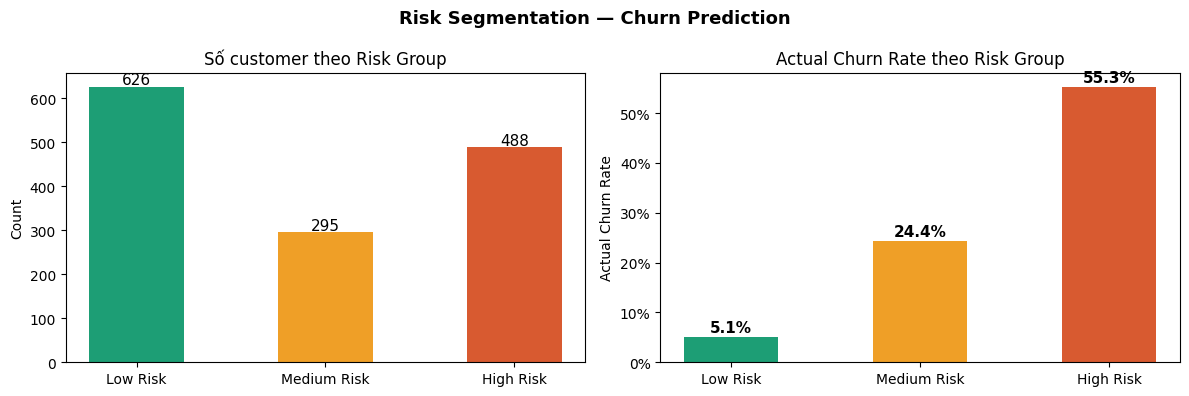

In [11]:
y_prob_test = best_model.predict_proba(X_test)[:, 1]
X_test_copy = X_test.copy()
X_test_copy["churn_prob"]  = y_prob_test
X_test_copy["actual_churn"] = y_test.values
X_test_copy["risk_group"] = pd.cut(
    y_prob_test,
    bins=[0, 0.3, 0.6, 1.0],
    labels=["Low Risk", "Medium Risk", "High Risk"],
)

print("=== Customer Distribution by Risk Group ===")
risk_dist = X_test_copy.groupby("risk_group", observed=True).agg(
    n_customers=("churn_prob", "count"),
    avg_churn_prob=("churn_prob", "mean"),
    actual_churn_rate=("actual_churn", "mean"),
    avg_monthly=("MonthlyCharges", "mean") if "MonthlyCharges" in X_test_copy.columns else ("churn_prob", "mean"),
)
print(risk_dist.round(3))

# Plot risk groups
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
risk_counts = X_test_copy["risk_group"].value_counts().sort_index()
colors_risk = ["#1D9E75", "#EF9F27", "#D85A30"]

axes[0].bar(risk_counts.index, risk_counts.values, color=colors_risk, width=0.5)
axes[0].set_title("Số customer theo Risk Group")
axes[0].set_ylabel("Count")
for i, (_, v) in enumerate(risk_counts.items()):
    axes[0].text(i, v + 5, str(v), ha="center", fontsize=11)

actual_rates = X_test_copy.groupby("risk_group", observed=True)["actual_churn"].mean()
axes[1].bar(actual_rates.index, actual_rates.values, color=colors_risk, width=0.5)
axes[1].set_title("Actual Churn Rate theo Risk Group")
axes[1].set_ylabel("Actual Churn Rate")
axes[1].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
for i, (_, v) in enumerate(actual_rates.items()):
    axes[1].text(i, v + 0.01, f"{v:.1%}", ha="center", fontsize=11, fontweight="bold")

plt.suptitle("Risk Segmentation — Churn Prediction", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{IMAGES}/risk_groups.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. SHAP Summary

In [12]:
print("="*65)
print("SHAP INSIGHTS — Ngôn ngữ Business")
print("="*65)
print("""
Dựa trên SHAP analysis, 5 yếu tố chính quyết định churn:

1. CONTRACT TYPE (quan trọng nhất)
   Month-to-month → SHAP dương lớn nhất
   → Khách không bị ràng buộc, dễ rời đi bất kỳ lúc nào
   ACTION: Ưu tiên chuyển khách sang long-term contract

2. TENURE (thời gian gắn bó)
   Tenure < 12 tháng → churn probability cao gấp đôi
   → Giai đoạn đầu là nguy hiểm nhất
   ACTION: Enhanced onboarding program, check-in call tháng 3

3. MONTHLY CHARGES
   Phí cao → tăng churn risk
   → Khách không cảm thấy value for money
   ACTION: Loyalty discount cho high-paying customers

4. TECH SUPPORT
   Không có TechSupport → tăng churn
   → Khi gặp vấn đề kỹ thuật, khách dễ bỏ sang đối thủ
   ACTION: Offer free TechSupport trial cho high-risk segment

5. INTERNET SERVICE TYPE
   Fiber optic → churn cao hơn DSL
   → Kỳ vọng cao hơn, thất vọng dễ hơn
   ACTION: Proactive quality monitoring cho Fiber customers
""")

SHAP INSIGHTS — Ngôn ngữ Business

Dựa trên SHAP analysis, 5 yếu tố chính quyết định churn:

1. CONTRACT TYPE (quan trọng nhất)
   Month-to-month → SHAP dương lớn nhất
   → Khách không bị ràng buộc, dễ rời đi bất kỳ lúc nào
   ACTION: Ưu tiên chuyển khách sang long-term contract

2. TENURE (thời gian gắn bó)
   Tenure < 12 tháng → churn probability cao gấp đôi
   → Giai đoạn đầu là nguy hiểm nhất
   ACTION: Enhanced onboarding program, check-in call tháng 3

3. MONTHLY CHARGES
   Phí cao → tăng churn risk
   → Khách không cảm thấy value for money
   ACTION: Loyalty discount cho high-paying customers

4. TECH SUPPORT
   Không có TechSupport → tăng churn
   → Khi gặp vấn đề kỹ thuật, khách dễ bỏ sang đối thủ
   ACTION: Offer free TechSupport trial cho high-risk segment

5. INTERNET SERVICE TYPE
   Fiber optic → churn cao hơn DSL
   → Kỳ vọng cao hơn, thất vọng dễ hơn
   ACTION: Proactive quality monitoring cho Fiber customers

